# Derivatives you already paid for

A surrogate is trained on solver output. The usual training set is a list of
(inputs, outputs) pairs: solve the model, keep the answer, throw the rest away.

The rest is not nothing. A converged interior-point solve ends holding a
factorized KKT matrix, and that factorization answers a second question for
almost free: **how does the answer move when a parameter moves?** One
back-solve per parameter returns $\partial y^\star/\partial p$ exactly — no
re-solve, no finite differences.

For the reactor in this notebook that is measured at **20 extra numbers per
solve for a 17% surcharge**. Bought the obvious way, by central finite
differences, the same 20 numbers cost **7.5&times;** a plain solve. So the
derivative labels are already in the room; the only question is whether a
surrogate can use them.

It can. Training on values *and* input-gradients — **Sobolev training**
(Czarnecki et al., 2017) — reaches a given accuracy with about **4&times;
fewer solves**, and at equal budget is **8&times;** more accurate on values
and **6&times;** on derivatives. On a downstream design problem the values-only
surrogate gives up 5.5% of the objective where the Sobolev one gives up 0.5%,
and still runs the reactor 1.6 K past its hot-spot limit at the largest budget,
where the Sobolev one is inside 0.1 K.

That is the easy half, and it is the half that is usually oversold. The hard
half is the weight. A Sobolev loss has a knob $\lambda$ between the value term
and the derivative term, and the standard fix — a negative-log-likelihood with
learned per-task variances — is widely sold as making the knob disappear. Two
sections of this notebook are spent taking that claim apart:

* The **unit-invariance** the NLL is usually credited with is delivered by
  z-scoring, not by the loss. Measured, all three losses here are invariant to
  a $10^9$ change of output units to within float roundoff.
* The **profiled** NLL beating the learned one is an optimization-speed
  effect, not a statistical one. They converge to the same place; profiling
  gets there ~4&times; sooner.

What the NLL does buy is real, and narrower than the sales pitch: channel
*spread* — which z-scoring removes — spans 13,395&times; here, while channel
*difficulty* spans 36&times;, and the two correlate at $\rho = -0.25$.
Weighting by achievable error is not something a normalizer can do.

Runtime: about 12 minutes, dominated by the learning-curve grid.

In [1]:
import platform, subprocess, time, functools, warnings
import importlib.metadata as meta
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc, spearmanr

import jax, jax.numpy as jnp, optax
jax.config.update("jax_enable_x64", True)

import pounce
from pounce.sensitivity import SensSession, NlBridge, solution

SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"python        {platform.python_version()}")
print(f"pounce-solver {meta.version('pounce-solver')}")
print(f"jax           {meta.version('jax')}")
print(f"optax         {meta.version('optax')}")
print(f"commit        {SOURCE_COMMIT[:12]}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(0)

python        3.12.11
pounce-solver 0.11.0
jax           0.11.0
optax         0.2.6
commit        07bf7ebf2591


## 1. The plant

A non-isothermal plug-flow reactor with a cooling jacket, carrying a series
reaction

$$\mathrm{A}\ \xrightarrow{\ k_1(T)\ }\ \mathrm{P}\ (\text{product})
\ \xrightarrow{\ k_2(T)\ }\ \mathrm{W}\ (\text{waste}),$$

with $E_2 > E_1$, so heat buys **rate** and costs **selectivity** — and both
reactions are exothermic, so the reactor makes its own heat. That is the whole
source of the nonlinearity: an interior hot spot whose position and height
depend on every parameter at once.

In dimensionless axial coordinate $z \in [0,1]$,

$$\frac{dC_A}{dz} = -\tau k_1 C_A, \qquad
\frac{dC_P}{dz} = \tau\,(k_1 C_A - k_2 C_P), $$
$$\frac{dT}{dz} = \tau\,\bigl(J_1 k_1 C_A + J_2 k_2 C_P - \beta (T - T_c)\bigr),$$

with $k_i = k_{i0}\exp[-\gamma_i(T_0/T - 1)]$ written about a reference $T_0$
so the exponents stay $O(1)$.

Five things the world sets, and the parameters we differentiate against:

| | | |
|---|---|---|
| $\tau$ | residence time | s |
| $T_{in}$ | inlet temperature | K |
| $T_c$ | coolant temperature | K |
| $C_{A0}$ | inlet concentration | mol/L |
| $\beta$ | jacket heat-transfer coefficient | 1/s |

Four things we want a surrogate for:

| | | |
|---|---|---|
| $X$ | conversion of A | — |
| $Y$ | yield of P | — |
| $T_{hot}$ | hot-spot temperature | K |
| $Q_c$ | cooling duty | K |

In [2]:
# ---- kinetics (reduced Arrhenius about T0, so the exponents stay O(1)) ----
T0 = 500.0
K10, K20 = 2.0, 0.20          # 1/s at T0
G1, G2 = 12.0, 20.0           # E/(R T0);  E2 > E1  =>  heat costs selectivity
J1, J2 = 60.0, 25.0           # adiabatic K per mol/L through each step

PARAM = ["tau", "Tin", "Tc", "CA0", "beta"]
OUT = ["X", "Y", "Thot", "Qc"]
UNIT = {"tau": "s", "Tin": "K", "Tc": "K", "CA0": "mol/L", "beta": "1/s",
        "X": "-", "Y": "-", "Thot": "K", "Qc": "K"}

LO = np.array([0.60, 480.0, 470.0, 0.80, 2.0])     # the sampling box
HI = np.array([1.60, 520.0, 510.0, 1.40, 4.5])
NOM = 0.5 * (LO + HI)

TREF, BSM = 600.0, 2.0        # smooth-max reference and sharpness (1/K)

### The hot spot needs a *smooth* maximum

$T_{hot}$ is the peak temperature along the reactor, and the obvious way to
write it — $\max_j T_j$ over the collocation nodes — is a trap for two
independent reasons.

It is **mesh-dependent**: the nodal maximum converges to the true peak only as
$O(h^2)$, and worse, it is a different function of the parameters on every
mesh.

It is **non-differentiable in the parameters**, which matters far more here.
As a parameter moves, the node holding the maximum switches, and
$\partial T_{hot}/\partial p$ jumps. Section 10 measures this: over a sweep of
$\tau$ the argmax node walks from 36 down to 26, and at every switch the hard
max's derivative flips sign, with jumps up to 0.82 K per unit $\tau$ — while
the value itself barely moves. A surrogate asked to learn that derivative field
is being asked to learn a sawtooth.

So $T_{hot}$ is a mesh-independent softmax, an integral rather than a sum:

$$T_{hot} = T_{ref} + \frac{1}{b}\log \int_0^1 e^{\,b\,(T(z) - T_{ref})}\,dz .$$

The integral form is the point — a *sum* over nodes would grow with $N$. This
one is stable to 4 decimals from $N = 500$ to $N = 4000$, and sits 1.11 K below
the true peak at $b = 2$: a deliberate, fixed bias, not mesh noise.

### Parameters are pinned rows

`pounce.sensitivity` addresses a parameter by the **equality row that pins
it**. There is no `make_parameter` in the Python layer: each parameter enters
as a *variable*, pinned by an equality whose right-hand side is its value, and
that row's index is the handle the sensitivity layer perturbs.

So the model below is a **square feasibility problem** — zero objective,
$n$ variables, $n$ constraint rows. Solving it just integrates the ODE by
trapezoid collocation. The five pin rows carry no information the solve needs;
they exist so that afterwards we can ask the factorization what happens if we
move them.

`bound_relax_factor = 0.0`, as always when the sensitivity layer is involved:
POUNCE relaxes bounds by a hair by default, and a coordinate sitting *outside*
its bound makes "on the bound" an ill-posed question.

In [3]:
def build(par, N=40, x0=None, design=None):
    """The PFR on N trapezoid intervals.

    `design=None` pins every parameter by an equality row: a square
    feasibility problem, and the pin rows are the sensitivity handles.
    `design=(T_lim, kappa)` instead frees the parameters inside the sampling
    box and maximizes `Y - kappa*Qc` subject to `Thot <= T_lim` -- the *true*
    design problem, on the same model the surrogate is trying to replace.
    """
    nz = N + 1
    n = 3 * nz + len(OUT) + len(PARAM)
    v = pounce.NlExpr.vars(n)
    CA, CP, T = v[0:nz], v[nz:2 * nz], v[2 * nz:3 * nz]
    X, Y, Thot, Qc = v[3 * nz:3 * nz + 4]
    tau, Tin, Tc, CA0, beta = v[3 * nz + 4:]
    ex = pounce.NlExpr.exp
    h = 1.0 / N

    def rhs(j):
        k1 = K10 * ex(-G1 * (T0 / T[j] - 1.0))
        k2 = K20 * ex(-G2 * (T0 / T[j] - 1.0))
        r1, r2 = k1 * CA[j], k2 * CP[j]
        return (tau * (-r1),
                tau * (r1 - r2),
                tau * (J1 * r1 + J2 * r2 - beta * (T[j] - Tc)))

    cons = [tau, Tin, Tc, CA0, beta]                 # 0..4   the pins
    cons += [CA[0] - CA0, CP[0], T[0] - Tin]         # 5..7   inlet
    f = [rhs(j) for j in range(nz)]
    for j in range(N):                               # trapezoid
        cons += [CA[j + 1] - CA[j] - 0.5 * h * (f[j][0] + f[j + 1][0]),
                 CP[j + 1] - CP[j] - 0.5 * h * (f[j][1] + f[j + 1][1]),
                 T[j + 1] - T[j] - 0.5 * h * (f[j][2] + f[j + 1][2])]

    w = [(1.0 if 0 < j < nz - 1 else 0.5) for j in range(nz)]   # trapezoid weights
    sm = pounce.NlExpr.sum([w[j] * h * ex(BSM * (T[j] - TREF)) for j in range(nz)])
    duty = pounce.NlExpr.sum([w[j] * (T[j] - Tc) for j in range(nz)])
    cons += [X * CA0 - (CA0 - CA[N]),
             Y * CA0 - CP[N],
             Thot - (TREF + pounce.NlExpr.log(sm) / BSM),
             Qc - tau * beta * h * duty]

    obj = pounce.NlExpr.const_(0.0)
    if design is not None:
        T_lim, kappa = design
        cons += [Thot]                                # the hot-spot limit
        obj = -(Y - kappa * Qc)

    m = len(cons)
    INF = 1e19
    if design is None:
        g_l = g_u = list(par) + [0.0] * (m - 5)
        pl, pu = [-INF] * 5, [INF] * 5
    else:
        g_l = [-INF] * 5 + [0.0] * (m - 6) + [-INF]
        g_u = [INF] * 5 + [0.0] * (m - 6) + [T_lim]
        pl, pu = list(LO), list(HI)
    x_l = [-INF] * (2 * nz) + [300.0] * nz + [-INF] * 4 + pl
    x_u = [INF] * (2 * nz) + [900.0] * nz + [INF] * 4 + pu
    if x0 is None:
        x0 = guess(par, N)
    names = ([f"CA{j}" for j in range(nz)] + [f"CP{j}" for j in range(nz)]
             + [f"T{j}" for j in range(nz)] + OUT + PARAM)
    rn = (["pin_" + p for p in PARAM] + ["in_CA", "in_CP", "in_T"]
          + [f"c{j}_{s}" for j in range(N) for s in "APT"]
          + ["def_" + o for o in OUT] + (["hot_lim"] if design else []))
    return pounce.build_nl_problem(
        n=n, objective=obj, constraints=cons, g_l=list(g_l), g_u=list(g_u),
        x_l=x_l, x_u=x_u, x0=list(x0),
        var_names=names, con_names=rn), n, m


def guess(par, N):
    """A crude cold start: flat profiles at the inlet condition.

    Deliberately *not* seeded from the reference integration below -- that
    would be starting from the answer, and would hide how hard the solve is.
    """
    tau, Tin, Tc, CA0, beta = par
    nz = N + 1
    return np.concatenate([np.full(nz, CA0), np.zeros(nz), np.full(nz, Tin),
                           [0.5, 0.4, Tin + 10.0, tau * beta * (Tin - Tc)], par])

In [4]:
def solve(par, N=40, x0=None):
    """Solve, and keep the session that holds the factorization."""
    nl, n, m = build(par, N, x0)
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl),
                          lb=nl.x_l, ub=nl.x_u, cl=nl.g_l, cu=nl.g_u)
    prob.add_option("bound_relax_factor", 0.0)   # required by the activity accessors
    prob.add_option("print_level", 0)
    solver = pounce.Solver(prob)
    x, info = solver.solve(np.asarray(nl.x0))
    sess = SensSession(nl, solver, list(range(nl.n)), list(range(nl.m)),
                       pins={p: i for i, p in enumerate(PARAM)})
    sess.base_x = np.asarray(x, float)
    sess.base_obj = float(info["obj_val"])
    return sess, info


def integrate(par, N=2000):
    """Reference: explicit RK4 on the same ODE. The truth the NLP approximates."""
    tau, Tin, Tc, CA0, beta = par
    h = 1.0 / N

    def f(s):
        CA, CP, T = s
        k1 = K10 * np.exp(-G1 * (T0 / T - 1.0))
        k2 = K20 * np.exp(-G2 * (T0 / T - 1.0))
        r1, r2 = k1 * CA, k2 * CP
        return np.array([tau * (-r1), tau * (r1 - r2),
                         tau * (J1 * r1 + J2 * r2 - beta * (T - Tc))])

    s = np.array([CA0, 0.0, Tin]); traj = [s.copy()]
    for _ in range(N):
        k1 = f(s); k2 = f(s + h/2*k1); k3 = f(s + h/2*k2); k4 = f(s + h*k3)
        s = s + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        traj.append(s.copy())
    traj = np.array(traj); Tz = traj[:, 2]
    w = np.ones(N + 1); w[0] = w[-1] = 0.5
    sm = TREF + np.log((w * np.exp(BSM * (Tz - TREF))).sum() * h) / BSM
    return dict(X=1 - traj[-1, 0]/CA0, Y=traj[-1, 1]/CA0, Thot=sm,
                Tmax=Tz.max(), Qc=tau*beta*h*(w*(Tz - Tc)).sum(), traj=traj)

In [5]:
ref = integrate(NOM, N=4000)
sess, info = solve(NOM, N=80)
nz = 81
OS = slice(3 * nz, 3 * nz + 4)

print(f"solve status {info['status']}   n = {sess.base_x.size} variables\n")
print(f"{'':>6s}{'NLP (N=80)':>14s}{'RK4 (N=4000)':>14s}{'rel err':>12s}")
for i, o in enumerate(OUT):
    a, b = sess.base_x[OS][i], ref[o]
    print(f"{o:>6s}{a:14.6f}{b:14.6f}{abs(a-b)/abs(b):12.2e}")
print(f"\nsmooth max sits {ref['Tmax'] - ref['Thot']:.2f} K below the true peak "
      f"{ref['Tmax']:.4f} K -- a fixed bias at b = {BSM}, not mesh noise.")

solve status 0   n = 252 variables

          NLP (N=80)  RK4 (N=4000)     rel err
     X      0.935281      0.935260    2.27e-05
     Y      0.750987      0.750974    1.73e-05
  Thot    515.341659    515.339128    4.91e-06
    Qc     67.830011     67.828827    1.75e-05

smooth max sits 1.11 K below the true peak 516.4494 K -- a fixed bias at b = 2.0, not mesh noise.


### Mesh convergence, and why $N = 80$

The collocation error has to be far below the surrogate's error, or we are
teaching the network our discretization. Trapezoid is second order, and the
check below confirms it: halving $h$ quarters the error.

At $N = 80$ the model is 252 variables and agrees with RK4 to $2\times10^{-5}$
relative — more than two orders below the best value NRMSE any surrogate in
this notebook reaches (0.005). The labels are effectively exact.

In [6]:
print(f"{'N':>6s}{'n':>7s}{'rel err in Y':>16s}{'ratio':>8s}{'ms/solve':>10s}")
prev = None
for N in (10, 20, 40, 80, 160):
    t = time.perf_counter()
    s, _ = solve(NOM, N=N)
    ms = (time.perf_counter() - t) * 1e3
    e = abs(s.base_x[3*(N+1)+1] - ref["Y"]) / abs(ref["Y"])
    r = "" if prev is None else f"{prev/e:8.2f}"
    print(f"{N:6d}{s.base_x.size:7d}{e:16.2e}{r:>8s}{ms:10.2f}")
    prev = e

N = 80
assert abs(solve(NOM, N=N)[0].base_x[3*(N+1)+1] - ref["Y"])/ref["Y"] < 1e-4

     N      n    rel err in Y   ratio  ms/solve
    10     42        1.12e-03              2.54
    20     72        2.78e-04    4.03      3.63
    40    132        6.94e-05    4.01      6.26
    80    252        1.73e-05    4.00     11.22
   160    492        4.34e-06    4.00     36.29


## 2. What a derivative label costs

This is the section the whole notebook rests on. If derivative labels cost as
much as extra solves, Sobolev training is just a worse way to spend a budget,
and the learning curves later are measured against the wrong x-axis.

Three ways to get $\partial y^\star/\partial p$ for the four outputs and five
parameters — a $4\times5$ Jacobian, 20 numbers:

1. **The held factorization.** `solution(sess, [k], [h])` perturbs pin row $k$
   by $h$ and back-solves the KKT system already factorized by the base solve.
   One back-solve per parameter. Nothing is re-solved.
2. **Central finite differences.** $2 n_p = 10$ extra full solves.
3. Not attempted: forward-mode AD through the solver, which POUNCE does not
   expose and which would cost more than (1) anyway.

Route (1) returns the *whole* moved state vector, not just the outputs — 252
numbers per parameter. We keep 4. That is what makes the hot-spot analysis in
section 10 free.

In [7]:
def jac_kkt(sess, y, H):
    """dy/dp by back-solve: one solve of the held KKT system per parameter."""
    return np.column_stack([(solution(sess, [k], [h], clamp=False)[OS] - y) / h
                            for k, h in enumerate(H)])


HJ = np.array([2e-3, 0.05, 0.05, 2e-3, 5e-3])     # back-solve step per parameter
HF = np.array([1e-3, 0.02, 0.02, 1e-3, 2e-3])     # central-FD step per parameter

REP = 20
t = time.perf_counter()
for _ in range(REP):
    s, _ = solve(NOM, N=N)
t_solve = (time.perf_counter() - t) / REP

y = s.base_x[OS].copy()
t = time.perf_counter()
for _ in range(REP):
    Jk = jac_kkt(s, y, HJ)
t_jac = (time.perf_counter() - t) / REP

print(f"one solve                       {t_solve*1e3:8.2f} ms")
print(f"the 4x5 Jacobian by back-solve  {t_jac*1e3:8.2f} ms   "
      f"({t_solve/t_jac:.1f}x cheaper than a solve)")
print(f"\n=> 20 derivative labels for a {1 + t_jac/t_solve:.2f}x surcharge on the solve.")

one solve                          10.59 ms
the 4x5 Jacobian by back-solve      1.80 ms   (5.9x cheaper than a solve)

=> 20 derivative labels for a 1.17x surcharge on the solve.


### The same 20 numbers, bought the obvious way

A back-solve is only a bargain if it is *right*. The check below buys the same
Jacobian by central differences — 10 extra solves per point — over 24 sampled
parameter vectors, and compares.

One subtlety in reading the result: a *relative* comparison blows up wherever a
derivative happens to pass through zero, which is a property of the arithmetic,
not a disagreement. So the table reports the difference scaled by each
channel's own typical magnitude.

In [8]:
def jac_fd(p, N=80):
    """The same Jacobian paid for with 2*n_p extra solves."""
    J = np.zeros((4, 5))
    for k, h in enumerate(HF):
        e = np.eye(5)[k] * h
        a = solve(p + e, N)[0].base_x[OS]
        b = solve(p - e, N)[0].base_x[OS]
        J[:, k] = (a - b) / (2 * h)
    return J


Pchk = qmc.scale(qmc.LatinHypercube(d=5, seed=4242).random(24), LO, HI)
K, F, tk, tf = [], [], 0.0, 0.0
for p in Pchk:
    t = time.perf_counter()
    ss, _ = solve(p, N); K.append(jac_kkt(ss, ss.base_x[OS].copy(), HJ))
    tk += time.perf_counter() - t
    t = time.perf_counter(); F.append(jac_fd(p, N)); tf += time.perf_counter() - t
K, F = np.array(K), np.array(F)

scaled = np.abs(K - F) / np.abs(F).mean(0)[None]
print("worst disagreement, scaled by that channel's mean |dy/dp|:")
print(f"{'':>6s}" + "".join(f"{p:>12s}" for p in PARAM))
for o in range(4):
    print(f"{OUT[o]:>6s}" + "".join(f"{scaled[:, o, k].max():12.2e}" for k in range(5)))
print(f"\nover all {K.size} entries: median {np.median(scaled):.2e}   max {scaled.max():.2e}")
print(f"\nper point:  solve + back-solve {tk/len(Pchk)*1e3:7.2f} ms"
      f"     solve + central FD {tf/len(Pchk)*1e3:7.2f} ms")
print(f"finite differences cost {tf/tk:.2f}x the held-factorization route "
      f"for numbers that agree to {scaled.max():.0e}.")
assert scaled.max() < 1e-4

worst disagreement, scaled by that channel's mean |dy/dp|:
               tau         Tin          Tc         CA0        beta
     X    6.63e-06    9.43e-08    1.26e-07    3.92e-07    5.43e-07
     Y    7.64e-06    1.42e-07    2.21e-07    1.37e-06    2.53e-06
  Thot    1.19e-06    8.76e-08    2.84e-07    5.88e-07    6.09e-07
    Qc    1.60e-06    3.00e-09    2.46e-08    9.66e-08    3.69e-06

over all 480 entries: median 8.43e-08   max 7.64e-06

per point:  solve + back-solve   15.53 ms     solve + central FD  117.09 ms
finite differences cost 7.54x the held-factorization route for numbers that agree to 8e-06.


The two routes agree to $10^{-5}$ of channel scale — four orders below the best
surrogate error in this notebook. **The label sets are interchangeable.** That
matters for how the learning curves are read: buying derivatives by finite
differences does not give you a *different*, worse dataset, it gives you the
same dataset at 7.5&times; the price. So the finite-difference arm is not a
separate accuracy curve, it is the same curve shifted along the cost axis, and
the plot in section 6 draws it that way.

## 3. The dataset

Latin-hypercube samples over the box, solved, with values and the $4\times5$
Jacobian kept for each. Five independent training pools of 256 so every number
later is a median over five draws rather than one lucky one, plus a held-out
test set of 1000.

Nothing here is thrown away for the values-only arm: **both arms see exactly
the same solves.** The values-only arm simply ignores the `J` array. That is
the honest comparison — the question is not whether more data helps, it is
whether the derivative labels that came free with the solve are worth using.

In [9]:
def one(p, N=80):
    sess, info = solve(p, N)
    if info["status"] != 0:
        return None
    y = sess.base_x[OS].copy()
    return y, jac_kkt(sess, y, HJ)


def dataset(n, seed, N=80):
    P = qmc.scale(qmc.LatinHypercube(d=5, seed=seed).random(n), LO, HI)
    ps, ys, Js = [], [], []
    for p in P:
        r = one(p, N)
        if r is None:
            continue
        ps.append(p); ys.append(r[0]); Js.append(r[1])
    return np.array(ps), np.array(ys), np.array(Js)


t = time.perf_counter()
Pt, Yt, Jt = dataset(1000, seed=90210)
POOLS = [dataset(256, seed=1000 + i) for i in range(5)]
gen_s = time.perf_counter() - t
nsolve = len(Pt) + sum(len(p) for p, _, _ in POOLS)
print(f"{nsolve} solves in {gen_s:.1f} s   "
      f"({len(Pt)}/1000 test, {[len(p) for p,_,_ in POOLS]} train)")
assert len(Pt) == 1000 and all(len(p) == 256 for p, _, _ in POOLS), \
    "a solve failed; the arms would no longer see identical data"

2280 solves in 35.5 s   (1000/1000 test, [256, 256, 256, 256, 256] train)


### The derivative channels are not on one scale

Before choosing a loss it is worth looking at what the 20 derivative channels
actually look like. They span four orders of magnitude in raw units, because
$\partial T_{hot}/\partial C_{A0}$ is 27 K per mol/L and $\partial Y/\partial
\tau$ is $6\times10^{-3}$ per second.

That spread is the entire reason a naive $\lambda$ is hopeless, and it is also
the reason z-scoring is not optional. Section 8 returns to what is left over
*after* z-scoring, which is the part that actually needs a decision.

In [10]:
sp = Jt.std(0)
print(f"{'':>6s}" + "".join(f"{p:>12s}" for p in PARAM))
for o in range(4):
    print(f"{OUT[o]:>6s}" + "".join(f"{Jt[:, o, k].mean():12.3e}" for k in range(5)))
print(f"\nchannel spread (std) spans {sp.max()/sp.min():.0f}x in raw units")
print(f"after z-scoring by each channel's std, by construction: 1x")

               tau         Tin          Tc         CA0        beta
     X   1.683e-01   1.831e-03   3.475e-03   7.976e-02  -2.272e-02
     Y   6.429e-03  -1.207e-03  -3.444e-03  -9.281e-02   2.924e-02
  Thot  -4.701e-01   6.073e-01   7.986e-01   2.743e+01  -5.984e+00
    Qc   3.336e+01   1.212e+00  -5.707e-01   6.057e+01   2.497e+00

channel spread (std) spans 13395x in raw units
after z-scoring by each channel's std, by construction: 1x


## 4. Two surrogates, one architecture

A 5&rarr;64&rarr;64&rarr;4 MLP with **tanh** activations, written as a pure
function of an explicit parameter pytree so `jax.jacrev` can differentiate the
network with respect to its *inputs* — which is the quantity being trained.

tanh, not ReLU, and not by taste: a ReLU network's input-gradient is piecewise
constant, so it cannot represent a varying derivative field at all. Section 10
measures what that costs (3.7&times; on derivatives for the Sobolev arm, and
only 1.6&times; for the values-only arm — the activation matters far more once
you train on gradients).

Inputs and outputs are z-scored. The Jacobian has to be normalized by the
**chain rule**, not by its own statistics:

$$\frac{\partial \tilde y}{\partial \tilde p}
= \frac{\sigma_p}{\sigma_y}\,\frac{\partial y}{\partial p},$$

so that the network's own input-gradient in normalized coordinates is the thing
being compared. Getting this wrong is silent — the loss still goes down.

In [11]:
class MLP:
    """A tanh MLP as a pure function of an explicit parameter pytree."""

    def __init__(self, nin=5, nout=4, width=64, depth=2, act=jnp.tanh):
        self.sizes = [nin] + [width] * depth + [nout]
        self.act = act

    def init(self, key):
        ks = jax.random.split(key, len(self.sizes) - 1)
        return [{"W": jax.random.normal(k, (a, b)) * jnp.sqrt(1.0 / a),
                 "b": jnp.zeros(b)}
                for k, a, b in zip(ks, self.sizes[:-1], self.sizes[1:])]

    def apply(self, th, p):
        h = p
        for lyr in th[:-1]:
            h = self.act(h @ lyr["W"] + lyr["b"])
        return h @ th[-1]["W"] + th[-1]["b"]


class Norm:
    """z-score inputs and outputs; carry the chain rule for the Jacobian."""

    def __init__(self, P, Y):
        self.mp, self.sp = P.mean(0), P.std(0)
        self.my, self.sy = Y.mean(0), Y.std(0)

    def p(self, P):   return (P - self.mp) / self.sp
    def y(self, Y):   return (Y - self.my) / self.sy
    def j(self, J):   return J * (self.sp[None, None, :] / self.sy[None, :, None])
    def unj(self, J): return J * (self.sy[None, :, None] / self.sp[None, None, :])
    def uny(self, Y): return Y * self.sy + self.my


model = MLP()

### The losses

All four operate on normalized residuals: $r^v$ is $4$ value residuals per
sample and $r^d$ is $20$ derivative residuals, for $K = 24$ *tasks* in total.

| | |
|---|---|
| values only | $\ \mathrm{mean}\,(r^v)^2$ |
| Sobolev, fixed $\lambda$ | $\ \mathrm{mean}\,(r^v)^2 + \lambda\,\mathrm{mean}\,(r^d)^2$ |
| NLL, learned $\sigma$ | $\ \sum_k \bigl[\tfrac12 \mathrm{MSE}_k e^{-s_k} + \tfrac12 s_k\bigr],\quad s_k = \log\sigma_k^2$ |
| NLL, profiled | $\ \tfrac12 \sum_k \log \mathrm{MSE}_k$ |

The last two are the same objective. Setting $\partial L/\partial s_k = 0$ in
the third gives $\hat\sigma_k^2 = \mathrm{MSE}_k$ exactly; substituting it back
gives the fourth, with $\sigma$ gone. The profiled form has **no extra
parameters at all** — and its gradient carries the adaptive weight $1/\mathrm{MSE}_k$,
so a task the network is currently bad at is automatically upweighted.

Section 8 shows that the difference between rows 3 and 4 is entirely about how
fast an optimizer reaches that stationary point, and that neither is the best
loss here at convergence.

In [12]:
def resid(th, model, P, Y, J):
    Yh = jax.vmap(model.apply, in_axes=(None, 0))(th, P)
    Jh = jax.vmap(jax.jacrev(model.apply, argnums=1), in_axes=(None, 0))(th, P)
    return Yh - Y, Jh - J


def flat(rv, rd):
    return jnp.concatenate([rv.reshape(rv.shape[0], -1),
                            rd.reshape(rd.shape[0], -1)], axis=1)   # (n, 24)


def loss_values(par, model, P, Y, J):
    rv, _ = resid(par["th"], model, P, Y, J)
    return jnp.mean(rv ** 2)


def loss_lambda(par, model, P, Y, J, lam):
    rv, rd = resid(par["th"], model, P, Y, J)
    return jnp.mean(rv ** 2) + lam * jnp.mean(rd ** 2)


def loss_lambda_chan(par, model, P, Y, J, lam, sd):
    """lam=1 after z-scoring each derivative channel: the strong cheap baseline."""
    rv, rd = resid(par["th"], model, P, Y, J)
    return jnp.mean(rv ** 2) + lam * jnp.mean((rd / sd[None]) ** 2)


def loss_nll(par, model, P, Y, J):
    """Learned per-task log-variance over the 4 value + 20 derivative tasks."""
    r = flat(*resid(par["th"], model, P, Y, J))
    s = par["logvar"]
    return jnp.mean(jnp.sum(0.5 * (r ** 2) * jnp.exp(-s) + 0.5 * s, axis=1))


def loss_profiled(par, model, P, Y, J, floor=1e-12):
    """sigma eliminated analytically: L = 1/2 sum_k log MSE_k."""
    r = flat(*resid(par["th"], model, P, Y, J))
    return 0.5 * jnp.sum(jnp.log(jnp.mean(r ** 2, axis=0) + floor))

### Training

Full-batch Adam with a cosine schedule and decoupled weight decay, the whole
loop inside one `jax.lax.scan`.

Full batch is not a shortcut. With $n \le 256$ a minibatch would only add
gradient noise, and it would make `loss_profiled` **biased**: the log of a batch
MSE is not the batch mean of log MSE.

The decay is applied by hand rather than through `optax.adamw` so that `wd`
stays a *traced* value. That lets `train_grid` vmap the entire
(pool &times; weight-decay) grid into one compiled computation, which is what
makes the learning curves below take minutes instead of an hour.

Weight decay is tuned, not fixed, and that is load-bearing. An untuned baseline
here reached train NRMSE 0.0000 against test 0.13 — it was not undertrained,
it was overfitting — and reporting against it overstated the Sobolev gap by
**2&times;**. So every arm gets the same weight-decay grid, selected per pool
on a held-out validation split, and selected on the **value** metric, which is
deliberately the baseline's own metric rather than one that favours the
Sobolev arms.

In [13]:
def init_params(model, key, ntask=24):
    return {"th": model.init(key), "logvar": jnp.zeros(ntask)}


def train(lossfn, model, P, Y, J, key, steps=5000, lr=3e-3, wd=0.0, **kw):
    """Full-batch Adam with decoupled weight decay, the loop inside one scan."""
    par = init_params(model, key)
    sched = optax.cosine_decay_schedule(lr, steps)
    opt = optax.adam(sched)
    st = opt.init(par)
    g = jax.value_and_grad(functools.partial(lossfn, model=model,
                                             P=P, Y=Y, J=J, **kw))

    def body(carry, i):
        par, st = carry
        v, gr = g(par)
        u, st = opt.update(gr, st, par)
        par = optax.apply_updates(par, u)
        f = 1.0 - sched(i) * wd                       # decoupled, weights only
        par = {"th": jax.tree.map(lambda w: w * f, par["th"]),
               "logvar": par["logvar"]}
        return (par, st), v

    (par, _), hist = jax.lax.scan(body, (par, st), jnp.arange(steps))
    return par, hist


def train_grid(lossfn, model, Ps, Ys, Js, keys, wds, steps=5000, lr=3e-3, **kw):
    """The full (pool x weight decay) outer product in one vmapped call."""
    f = functools.partial(train, lossfn, model, steps=steps, lr=lr, **kw)
    over_wd = jax.vmap(lambda P, Y, J, k, w: f(P, Y, J, k, wd=w),
                       in_axes=(None, None, None, None, 0))
    return jax.jit(jax.vmap(over_wd, in_axes=(0, 0, 0, 0, None)))(Ps, Ys, Js, keys, wds)


def predict(model, par, nz_, P):
    Pn = jnp.asarray(nz_.p(P))
    Yn = jax.vmap(model.apply, in_axes=(None, 0))(par["th"], Pn)
    Jn = jax.vmap(jax.jacrev(model.apply, argnums=1), in_axes=(None, 0))(par["th"], Pn)
    return nz_.uny(np.asarray(Yn)), nz_.unj(np.asarray(Jn))


def nrmse(pred, true):
    """Per-channel RMSE normalized by that channel's test std; mean over channels."""
    e = (pred - true).reshape(len(pred), -1)
    return float(np.mean(np.sqrt((e ** 2).mean(0)) / true.reshape(len(true), -1).std(0)))


def evaluate(model, par, nz_, Pt, Yt, Jt):
    Yh, Jh = predict(model, par, nz_, Pt)
    return nrmse(Yh, Yt), nrmse(Jh, Jt)


def pick(par, i, j):
    """One (pool, wd) slice out of a train_grid result."""
    return {"th": jax.tree.map(lambda a: a[i, j], par["th"]),
            "logvar": par["logvar"][i, j]}

## 5. Learning curves

The headline experiment: three arms, five training-set sizes, five pools each,
weight decay selected on a validation split per (arm, size, pool).

* **values** — `loss_values`, ignores `J` entirely
* **Sobolev, $\lambda = 1$** — the naive Sobolev loss
* **Sobolev, NLL** — the profiled negative log-likelihood, no weight to choose

Read the x-axis as *solves*, which is the quantity that costs money. All three
arms consume the same number of solves at a given $n$; the Sobolev arms
additionally consume the derivative labels, which section 2 measured at a 17%
surcharge and which the second plot puts on a wall-clock axis.

In [14]:
NS = [16, 32, 64, 128, 256]
WDS = jnp.array([0.0, 0.03, 0.1, 0.3, 1.0])
STEPS = 5000
ARMS = [("values",          loss_values,   {}),
        ("sobolev lam=1",   loss_lambda,   dict(lam=1.0)),
        ("sobolev NLL",     loss_profiled, {})]

curves = {a: {"val": [], "der": [], "wd": []} for a, _, _ in ARMS}
t0 = time.perf_counter()
for n in NS:
    ntr = (n * 3) // 4                                  # 75/25 train/validate
    Ps, Ys, Js, zs, hold = [], [], [], [], []
    for P0, Y0, J0 in POOLS:
        P0, Y0, J0 = P0[:n], Y0[:n], J0[:n]
        z = Norm(P0[:ntr], Y0[:ntr]); zs.append(z)
        Ps.append(z.p(P0[:ntr])); Ys.append(z.y(Y0[:ntr])); Js.append(z.j(J0[:ntr]))
        hold.append((P0[ntr:], Y0[ntr:]))
    Ps, Ys, Js = (jnp.asarray(np.array(a)) for a in (Ps, Ys, Js))
    keys = jnp.stack([jax.random.PRNGKey(7 + i) for i in range(len(POOLS))])

    for name, fn, kw in ARMS:
        par, _ = train_grid(fn, model, Ps, Ys, Js, keys, WDS, steps=STEPS, **kw)
        got = []
        for i in range(len(POOLS)):
            sc = [nrmse(predict(model, pick(par, i, j), zs[i], hold[i][0])[0], hold[i][1])
                  for j in range(len(WDS))]
            j = int(np.argmin(sc))                      # select on VALUE error
            got.append(evaluate(model, pick(par, i, j), zs[i], Pt, Yt, Jt)
                       + (float(WDS[j]),))
        for k, key in enumerate(("val", "der", "wd")):
            curves[name][key].append(np.median([g[k] for g in got]))
print(f"{len(NS)*len(ARMS)*len(POOLS)*len(WDS)} trainings in {time.perf_counter()-t0:.0f} s")

375 trainings in 167 s


In [15]:
for lbl, key in (("value", "val"), ("derivative", "der")):
    print(f"\n--- median test {lbl} NRMSE over {len(POOLS)} pools ---")
    print(f"{'n':>6s}" + "".join(f"{a:>18s}" for a, _, _ in ARMS))
    for i, n in enumerate(NS):
        print(f"{n:6d}" + "".join(f"{curves[a][key][i]:18.4f}" for a, _, _ in ARMS))
print("\nselected weight decay (median over pools):")
for a, _, _ in ARMS:
    print(f"  {a:18s}" + "".join(f"{w:7.2f}" for w in curves[a]["wd"]))


--- median test value NRMSE over 5 pools ---
     n            values     sobolev lam=1       sobolev NLL
    16            0.4538            0.2385            0.2225
    32            0.2975            0.1006            0.0868
    64            0.1792            0.0602            0.0394
   128            0.0805            0.0228            0.0123
   256            0.0414            0.0123            0.0053

--- median test derivative NRMSE over 5 pools ---
     n            values     sobolev lam=1       sobolev NLL
    16            2.3577            1.5878            1.3848
    32            2.2389            0.9010            0.7300
    64            1.5930            0.5884            0.3422
   128            0.8526            0.3825            0.1876
   256            0.6122            0.2508            0.1011

selected weight decay (median over pools):
  values               1.00   1.00   1.00   0.30   0.30
  sobolev lam=1        0.30   0.30   0.30   0.03   0.03
  sobolev NLL  

at n = 256:  value 7.8x more accurate, derivative 6.1x
the Sobolev arm reaches the values arm's best accuracy (0.0414) at n = 64, i.e. 4x fewer solves


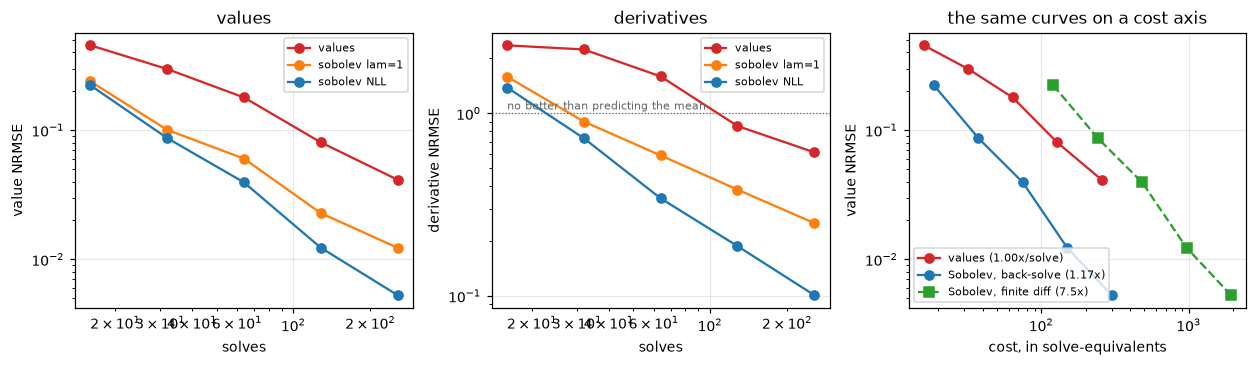

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.4))
CL = {"values": "tab:red", "sobolev lam=1": "tab:orange", "sobolev NLL": "tab:blue"}
for a, _, _ in ARMS:
    ax[0].loglog(NS, curves[a]["val"], "o-", color=CL[a], label=a)
    ax[1].loglog(NS, curves[a]["der"], "o-", color=CL[a], label=a)
ax[0].set(xlabel="solves", ylabel="value NRMSE", title="values")
ax[1].set(xlabel="solves", ylabel="derivative NRMSE", title="derivatives")
ax[1].axhline(1.0, color="0.4", lw=0.8, ls=":")
ax[1].annotate("no better than predicting the mean", (NS[0], 1.05), fontsize=7, color="0.4")

# the cost axis: derivative labels are a 17% surcharge, FD would be 7.5x
SUR = 1 + t_jac / t_solve
ax[2].loglog(np.array(NS), curves["values"]["val"], "o-", color=CL["values"],
             label="values (1.00x/solve)")
ax[2].loglog(np.array(NS) * SUR, curves["sobolev NLL"]["val"], "o-", color=CL["sobolev NLL"],
             label=f"Sobolev, back-solve ({SUR:.2f}x)")
ax[2].loglog(np.array(NS) * (tf / tk), curves["sobolev NLL"]["val"], "s--",
             color="tab:green", label=f"Sobolev, finite diff ({tf/tk:.1f}x)")
ax[2].set(xlabel="cost, in solve-equivalents", ylabel="value NRMSE",
          title="the same curves on a cost axis")
for a_ in ax:
    a_.legend(fontsize=7)
fig.tight_layout()

v0, v1 = curves["values"]["val"][-1], curves["sobolev NLL"]["val"][-1]
d0, d1 = curves["values"]["der"][-1], curves["sobolev NLL"]["der"][-1]
print(f"at n = {NS[-1]}:  value {v0/v1:.1f}x more accurate, derivative {d0/d1:.1f}x")
tgt = curves["values"]["val"][-1]
reach = next(n for n, v in zip(NS, curves["sobolev NLL"]["val"]) if v <= tgt)
print(f"the Sobolev arm reaches the values arm's best accuracy ({tgt:.4f}) "
      f"at n = {reach}, i.e. {NS[-1]/reach:.0f}x fewer solves")

Two things to read off, and one warning.

The **derivative** panel is the stark one. The values-only surrogate sits at or
above NRMSE 1 for most of the range — a model of the derivative field no better
than predicting its mean — while having a perfectly respectable value error.
This is the practical case for Sobolev training in one picture: if anything
downstream differentiates the surrogate (an optimizer, a controller, a
sensitivity study), the values-only surrogate is not fit for it, and its *value*
error will not tell you so.

The **cost** panel is where the sensitivity layer earns its place. Bought by
finite differences the Sobolev curve shifts right by 7.5&times; and the
advantage over the values arm mostly evaporates in the mid-range. Bought from
the factorization the shift is 1.17&times; and is barely visible. The argument
for Sobolev training is not really about the loss — it is about whether the
labels are cheap, and here they are cheap because the solve already computed
them.

The warning: `selected weight decay` drifts to 0 for the Sobolev NLL arm at
large $n$ while the values arm stays at 0.3. The derivative term is acting as a
regularizer, which is a real part of why it helps — and a reminder that any
comparison against an *un-regularized* baseline is measuring the wrong thing.

## 6. Parity

Learning curves compress each surrogate to one number per axis. The parity
plots show where the error actually lives, at a single $n = 64$.

values only    derivative NRMSE  mean over 20 channels 1.1660   median 0.5475   channels worse than the mean predictor: 3/20
Sobolev NLL    derivative NRMSE  mean over 20 channels 0.2821   median 0.1254   channels worse than the mean predictor: 1/20


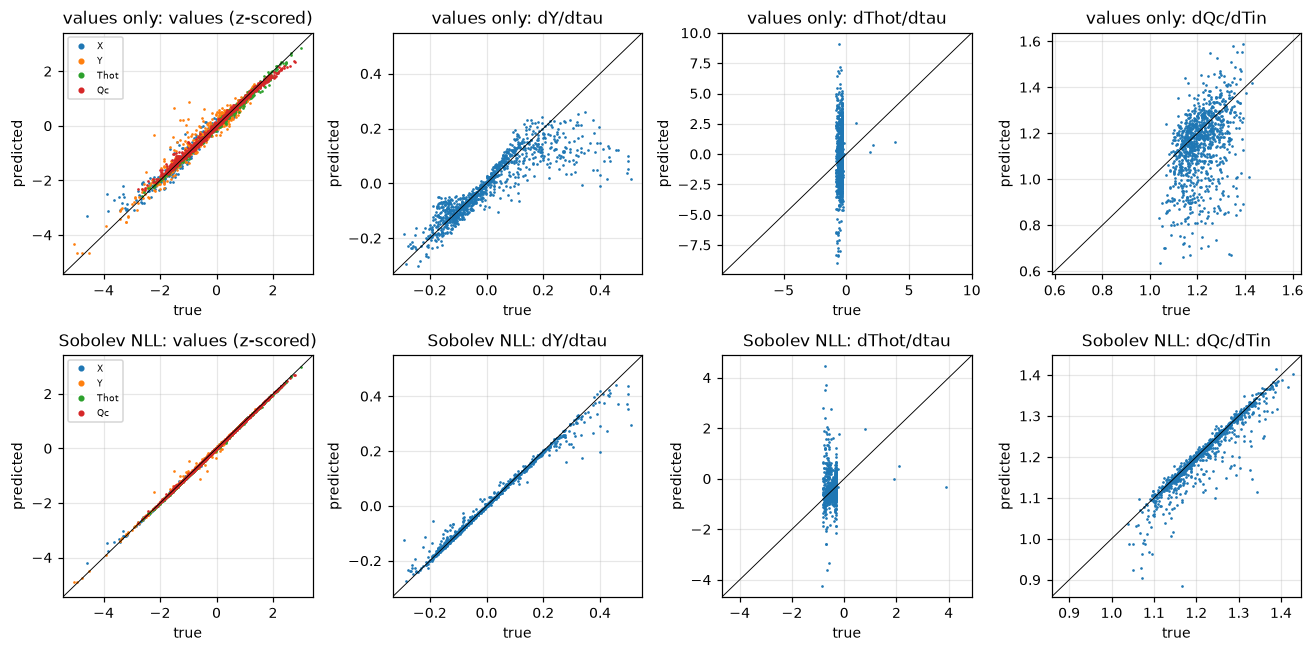

In [17]:
n_par = 64
P0, Y0, J0 = POOLS[0][0][:n_par], POOLS[0][1][:n_par], POOLS[0][2][:n_par]
zp = Norm(P0, Y0)
args = (jnp.asarray(zp.p(P0)), jnp.asarray(zp.y(Y0)), jnp.asarray(zp.j(J0)))
par_v, _ = train(loss_values, model, *args, jax.random.PRNGKey(7), steps=STEPS, wd=1.0)
par_s, _ = train(loss_profiled, model, *args, jax.random.PRNGKey(7), steps=STEPS, wd=0.1)
Yv, Jv = predict(model, par_v, zp, Pt)
Ys_, Js_ = predict(model, par_s, zp, Pt)

fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for c, (nm, Yh, Jh) in enumerate((("values only", Yv, Jv), ("Sobolev NLL", Ys_, Js_))):
    a = ax[c, 0]
    for i, o in enumerate(OUT):                      # values, z-scored to share axes
        a.plot((Yt[:, i]-Yt[:, i].mean())/Yt[:, i].std(),
               (Yh[:, i]-Yt[:, i].mean())/Yt[:, i].std(), ".", ms=1.5, label=o)
    a.set(title=f"{nm}: values (z-scored)", xlabel="true", ylabel="predicted")
    a.legend(fontsize=6, markerscale=4)
    for k, (o, p) in enumerate(((1, 0), (2, 0), (3, 1))):   # three derivative channels
        a = ax[c, k+1]
        a.plot(Jt[:, o, p], Jh[:, o, p], ".", ms=1.5, color="tab:blue")
        a.set(title=f"{nm}: d{OUT[o]}/d{PARAM[p]}", xlabel="true", ylabel="predicted")
for a in ax.ravel():
    lo_, hi_ = min(a.get_xlim()[0], a.get_ylim()[0]), max(a.get_xlim()[1], a.get_ylim()[1])
    a.plot([lo_, hi_], [lo_, hi_], "k-", lw=0.6); a.set_xlim(lo_, hi_); a.set_ylim(lo_, hi_)
fig.tight_layout()

for nm, Jh in (("values only", Jv), ("Sobolev NLL", Js_)):
    nr = np.sqrt(((Jh - Jt) ** 2).mean(0)) / Jt.std(0)
    print(f"{nm:14s} derivative NRMSE  mean over 20 channels {nr.mean():.4f}   "
          f"median {np.median(nr):.4f}   channels worse than the mean predictor: {(nr>1).sum()}/20")

### One channel dominates the mean, and it is worth knowing which

$\partial T_{hot}/\partial \tau$ is by a wide margin the hardest of the 20
channels for **both** arms, and because the reported metric is a mean over
channels, that one channel carries about half of the Sobolev arm's derivative
NRMSE. Two checks before that number is trusted:

* Is it a normalization artifact — a channel with tiny spread? **No.** Its
  coefficient of variation across the box is 0.49, unremarkable.
* Does the arm *ranking* survive removing it? **Yes.** Mean over channels gives
  a 4.1&times; gap, median over channels 4.4&times;. The headline is not an
  artifact of the outlier.

What it actually is: the most **nonlinear** channel in the set. Fitting a linear
model in $p$ to each channel and measuring the residual, this one leaves 0.85
of its variance unexplained against 0.49 for the runner-up. A first check that
the culprit was proximity to the reactor's other regime — the parameter
combinations that never develop an interior hot spot at all — was **measured
and rejected**. Those points are 0.7% of the test box and carry 1.5% of this
channel's squared error, and the error correlates with the inlet temperature
slope at only $\rho = +0.16$. The hard points are not the ones near the regime
boundary; the channel is simply a hard function.

In [18]:
A_ = np.column_stack([np.ones(len(Pt)), (Pt - Pt.mean(0)) / Pt.std(0)])
def nonlin(v):
    c, *_ = np.linalg.lstsq(A_, v, rcond=None)
    return np.sqrt(((v - A_ @ c) ** 2).mean()) / v.std()

print("residual of a linear fit in p (1.0 = linear model explains nothing):")
print(f"{'':>6s}" + "".join(f"{p:>10s}" for p in PARAM))
for o in range(4):
    print(f"{OUT[o]:>6s}" + "".join(f"{nonlin(Jt[:, o, k]):10.3f}" for k in range(5)))

nr = np.sqrt(((Js_ - Jt) ** 2).mean(0)) / Jt.std(0)
nrv = np.sqrt(((Jv - Jt) ** 2).mean(0)) / Jt.std(0)
cv = Jt.std(0) / np.abs(Jt.mean(0))
print(f"\ndThot/dtau: nonlinearity {nonlin(Jt[:,2,0]):.3f} (highest), "
      f"coefficient of variation {cv[2,0]:.3f} (unremarkable)")
print(f"arm ratio, mean over channels   {nrv.mean()/nr.mean():.2f}x")
print(f"arm ratio, median over channels {np.median(nrv)/np.median(nr):.2f}x")

# Is the culprit proximity to the no-hot-spot regime?  A point whose temperature
# already falls at the inlet never develops an interior peak, and that test is
# closed form in p -- no solve needed.
k1_0 = K10 * np.exp(-G1 * (T0 / Pt[:, 1] - 1.0))
slope0 = J1 * k1_0 * Pt[:, 3] - Pt[:, 4] * (Pt[:, 1] - Pt[:, 2])
cold = slope0 <= 0.0
e2 = (Js_[:, 2, 0] - Jt[:, 2, 0]) ** 2
print(f"\nno interior hot spot (dT/dz <= 0 at the inlet): "
      f"{100*cold.mean():.1f}% of the test box, carrying "
      f"{100*e2[cold].sum()/e2.sum():.1f}% of the squared error in dThot/dtau")
print(f"spearman(inlet slope, |error| in dThot/dtau) = "
      f"{spearmanr(slope0, np.abs(Js_[:, 2, 0] - Jt[:, 2, 0]))[0]:+.3f}")

residual of a linear fit in p (1.0 = linear model explains nothing):
             tau       Tin        Tc       CA0      beta
     X     0.394     0.338     0.222     0.291     0.356
     Y     0.417     0.375     0.192     0.340     0.455
  Thot     0.848     0.215     0.422     0.288     0.354
    Qc     0.307     0.486     0.270     0.283     0.395

dThot/dtau: nonlinearity 0.848 (highest), coefficient of variation 0.487 (unremarkable)
arm ratio, mean over channels   4.13x
arm ratio, median over channels 4.36x

no interior hot spot (dT/dz <= 0 at the inlet): 0.7% of the test box, carrying 1.5% of the squared error in dThot/dtau
spearman(inlet slope, |error| in dThot/dtau) = +0.157


## 7. The weight between values and derivatives

This is the section the notebook was really built for. A Sobolev loss has a
knob:

$$L = \mathrm{mean}\,(r^v)^2 + \lambda\,\mathrm{mean}\,(r^d)^2 .$$

$\lambda$ is not a detail. Swept over six orders it moves the value error by
5&times; and the derivative error by 4&times;, and it has no natural setting —
it is a ratio between quantities in different units.

In [19]:
n_z = 64
AZ, sds = [], []
for P0, Y0, J0 in POOLS:
    P0, Y0, J0 = P0[:n_z], Y0[:n_z], J0[:n_z]
    z = Norm(P0, Y0)
    AZ.append((z, jnp.asarray(z.p(P0)), jnp.asarray(z.y(Y0)), jnp.asarray(z.j(J0))))
    sds.append(np.asarray(z.j(J0)).std(0))
SD = jnp.asarray(np.median(sds, axis=0))


def run(fn, steps=STEPS, wd=0.1, **kw):
    r = [evaluate(model, train(fn, model, P, Y, J, jax.random.PRNGKey(7+i),
                               steps=steps, wd=wd, **kw)[0], z, Pt, Yt, Jt)
         for i, (z, P, Y, J) in enumerate(AZ)]
    return np.median([x[0] for x in r]), np.median([x[1] for x in r])


LAMS = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
sweep = [run(loss_lambda, lam=l) for l in LAMS]
print(f"lambda sweep at n = {n_z} (median over {len(AZ)} pools, wd = 0.1)")
for l, (v, e) in zip(LAMS, sweep):
    print(f"  lam = {l:8.4g}   val {v:.4f}   der {e:.4f}")
best_lam = LAMS[int(np.argmin([v for v, _ in sweep]))]
print(f"\nbest lambda by value error: {best_lam:g}   "
      f"(value error moves {max(v for v,_ in sweep)/min(v for v,_ in sweep):.1f}x across the sweep)")

lambda sweep at n = 64 (median over 5 pools, wd = 0.1)
  lam =   0.0001   val 0.1654   der 1.7051
  lam =    0.001   val 0.1547   der 1.6157
  lam =     0.01   val 0.1056   der 1.0977
  lam =      0.1   val 0.0559   der 0.7362
  lam =        1   val 0.0345   der 0.4468
  lam =       10   val 0.0304   der 0.4435
  lam =      100   val 0.0301   der 0.4295

best lambda by value error: 100   (value error moves 5.5x across the sweep)


### The zoo

Six losses at $n = 64$. One deserves introduction:

* **`sobolev chan z-scored`** is $\lambda = 1$ applied *after* z-scoring each
  of the 20 derivative residuals by its own spread. It is nearly free — one
  extra `std` — and it is the baseline the NLL has to beat to be worth
  anything. It is included precisely because it is the strong cheap option
  that such comparisons usually omit.

In [20]:
ZOO = [("values only",            loss_values,      {}),
       ("sobolev lam=1",          loss_lambda,      dict(lam=1.0)),
       (f"sobolev lam={best_lam:g} (best)", loss_lambda, dict(lam=best_lam)),
       ("sobolev chan z-scored",  loss_lambda_chan, dict(lam=1.0, sd=SD)),
       ("NLL 24 tasks learned",   loss_nll,         {}),
       ("NLL 24 tasks profiled",  loss_profiled,    {})]
zoo = {nm: run(fn, **kw) for nm, fn, kw in ZOO}
print(f"{'loss':>28s}{'val NRMSE':>12s}{'der NRMSE':>12s}")
for nm, _, _ in ZOO:
    print(f"{nm:>28s}{zoo[nm][0]:12.4f}{zoo[nm][1]:12.4f}")

                        loss   val NRMSE   der NRMSE
                 values only      0.1667      1.7129
               sobolev lam=1      0.0345      0.4468
      sobolev lam=100 (best)      0.0301      0.4295
       sobolev chan z-scored      0.0501      0.3425
        NLL 24 tasks learned      0.0342      0.4292
       NLL 24 tasks profiled      0.0222      0.2639


### Two corrections to the usual story

The table above says the profiled NLL is the best loss, and every arm beats
values-only by a lot. The second half of that is solid. The first half is a
**training-budget artifact**, and two experiments show it.

**Correction 1: learned vs profiled is about optimization speed, not
statistics.** They are the same objective. At 5000 steps the profiled form
looks 1.5&times; better; by 20 000 steps they are indistinguishable. The reason
is visible in the learned form's own stationarity condition, $\sigma_k^2 =
\mathrm{MSE}_k$: at 5000 steps `logvar` is still **4.8 log-units** — a factor
of 120 — away from satisfying it, so for most of training the "learned"
weights are sitting near their initialization and the loss is behaving like
$\lambda = 1$. Profiling imposes the condition exactly at every step instead of
letting a gradient walk there.

In [21]:
print(f"{'steps':>8s}{'learned val':>14s}{'learned der':>14s}"
      f"{'profiled val':>14s}{'profiled der':>14s}{'|log(var/MSE)| med':>22s}")
for steps in (5000, 20000):
    lv = run(loss_nll, steps=steps)
    pv = run(loss_profiled, steps=steps)
    z, P, Y, J = AZ[0]
    p_, _ = train(loss_nll, model, P, Y, J, jax.random.PRNGKey(7), steps=steps, wd=0.1)
    r = flat(*resid(p_["th"], model, P, Y, J))
    gap = np.abs(np.log(np.exp(np.asarray(p_["logvar"])) / np.asarray(jnp.mean(r**2, 0))))
    print(f"{steps:8d}{lv[0]:14.4f}{lv[1]:14.4f}{pv[0]:14.4f}{pv[1]:14.4f}"
          f"{np.median(gap):22.3f}")

   steps   learned val   learned der  profiled val  profiled der    |log(var/MSE)| med


    5000        0.0342        0.4292        0.0222        0.2639                 4.765


   20000        0.0199        0.2461        0.0216        0.2346                 0.289


**Correction 2: at convergence, the parameter-free NLL does not win.** Given
enough steps, $\lambda = 1$ after per-channel z-scoring — the cheap baseline —
beats it on both metrics.

So the honest summary of the NLL is narrower than the sales pitch, and it is
still useful: it is *competitive without a sweep*. The tuned-$\lambda$ and
z-scored arms each needed either a seven-point sweep or a design decision about
what to normalize by; the NLL needed nothing and landed in the same
neighbourhood. At a short budget it is ahead outright. That is a real
convenience — it is just not a better optimum.

In [22]:
FAIR = [("values only",           loss_values,      {}),
        ("sobolev lam=1",         loss_lambda,      dict(lam=1.0)),
        (f"sobolev lam={best_lam:g}", loss_lambda,  dict(lam=best_lam)),
        ("sobolev chan z-scored", loss_lambda_chan, dict(lam=1.0, sd=SD)),
        ("NLL 24 profiled",       loss_profiled,    {})]
print(f"{'loss':>26s}{'5k val':>10s}{'5k der':>10s}{'20k val':>10s}{'20k der':>10s}")
fair = {}
for nm, fn, kw in FAIR:
    a, b = run(fn, steps=5000, **kw), run(fn, steps=20000, **kw)
    fair[nm] = (a, b)
    print(f"{nm:>26s}{a[0]:10.4f}{a[1]:10.4f}{b[0]:10.4f}{b[1]:10.4f}")

win5 = min((k for k in fair if k != "values only"), key=lambda k: fair[k][0][0])
win20 = min((k for k in fair if k != "values only"), key=lambda k: fair[k][1][0])
print(f"\nbest at  5k steps: {win5}")
print(f"best at 20k steps: {win20}")
print("\nvalues-only does NOT improve with the longer budget "
      f"({fair['values only'][0][0]:.4f} -> {fair['values only'][1][0]:.4f}): "
      "it is saturated, not undertrained,\nso the Sobolev gap is not a budget artifact -- it grows.")

                      loss    5k val    5k der   20k val   20k der


               values only    0.1667    1.7129    0.1485    1.5300


             sobolev lam=1    0.0345    0.4468    0.0382    0.4554


           sobolev lam=100    0.0301    0.4295    0.0187    0.2142


     sobolev chan z-scored    0.0501    0.3425    0.0160    0.1501


           NLL 24 profiled    0.0222    0.2639    0.0216    0.2346

best at  5k steps: NLL 24 profiled
best at 20k steps: sobolev chan z-scored

values-only does NOT improve with the longer budget (0.1667 -> 0.1485): it is saturated, not undertrained,
so the Sobolev gap is not a budget artifact -- it grows.


### What the NLL is *not* buying: unit invariance

The standard argument for a learned-variance loss is that it removes the need
to know what units things are in. Here that argument is **vacuous**, and it is
worth showing rather than asserting, because it is the claim most likely to be
repeated.

Re-express the outputs in absurd units — conversion in ppm, hot-spot in
millikelvin, duty in megawatts, a $10^9$ range of rescalings — z-score as usual,
train, and map the predictions back. If a loss were unit-sensitive, its answer
would move.

In [23]:
MULT = np.array([1e6, 1.0, 1e3, 1e-3])          # ppm, -, mK, MW
P0, Y0, J0 = POOLS[0][0][:n_z], POOLS[0][1][:n_z], POOLS[0][2][:n_z]
print(f"{'loss':>22s}{'SI val':>10s}{'rescaled':>10s}{'SI der':>10s}{'rescaled':>10s}{'max rel diff':>14s}")
for nm, fn, kw in (("values only", loss_values, {}),
                   ("sobolev lam=1", loss_lambda, dict(lam=1.0)),
                   ("NLL 24 profiled", loss_profiled, {})):
    got = []
    for mult in (np.ones(4), MULT):
        Ys2, Js2 = Y0 * mult, J0 * mult[None, :, None]
        z = Norm(P0, Ys2)
        p_, _ = train(fn, model, jnp.asarray(z.p(P0)), jnp.asarray(z.y(Ys2)),
                      jnp.asarray(z.j(Js2)), jax.random.PRNGKey(7),
                      steps=STEPS, wd=0.1, **kw)
        Yh, Jh = predict(model, p_, z, Pt)
        got.append((Yh / mult, Jh / mult[None, :, None]))    # back to SI
    (Ya, Ja), (Yb, Jb) = got
    rel = max(np.abs(Ya-Yb).max()/np.abs(Ya).max(), np.abs(Ja-Jb).max()/np.abs(Ja).max())
    print(f"{nm:>22s}{nrmse(Ya,Yt):10.4f}{nrmse(Yb,Yt):10.4f}"
          f"{nrmse(Ja,Jt):10.4f}{nrmse(Jb,Jt):10.4f}{rel:14.2e}")

                  loss    SI val  rescaled    SI der  rescaled  max rel diff


           values only    0.1667    0.1667    1.6232    1.6232      1.76e-14


         sobolev lam=1    0.0421    0.0422    0.5556    0.5559      2.26e-04


       NLL 24 profiled    0.0254    0.0259    0.2821    0.2841      1.75e-02


All three are invariant. `values only` is invariant to $10^{-14}$ — machine
precision, because z-scoring makes the two losses *identical*. The Sobolev and
NLL rows differ by $10^{-4}$ and $10^{-2}$, which is float roundoff amplified
by 5000 Adam steps, not a change of answer: both are well inside the
pool-to-pool spread.

**Unit invariance is delivered by the normalizer, not by the loss.** Any loss
placed after a z-scoring step gets it for free, so it is not a reason to prefer
one.

### What the NLL *is* buying: weighting by difficulty

Here is the thing z-scoring genuinely cannot do. z-scoring equalizes each
channel's **spread**. The NLL's weights converge to each channel's **achievable
error**. These are different quantities, and in this dataset they are almost
unrelated.

In [24]:
diff = (np.sqrt(((Js_ - Jt) ** 2).mean(0)) / Jt.std(0)).ravel()   # realized difficulty
spread = Jt.std(0).ravel()
print(f"channel spread spans     {spread.max()/spread.min():8.0f}x")
print(f"channel difficulty spans {diff.max()/diff.min():8.0f}x")
print(f"spearman(spread, difficulty) = {spearmanr(spread, diff).statistic:+.3f}")
print("\n=> equalizing by spread is not equalizing by difficulty.")
print("   A normalizer can do the first. Only a loss that watches its own")
print("   residuals can do the second.")

channel spread spans        13395x
channel difficulty spans       36x
spearman(spread, difficulty) = -0.248

=> equalizing by spread is not equalizing by difficulty.
   A normalizer can do the first. Only a loss that watches its own
   residuals can do the second.


## 8. Does any of it matter downstream?

NRMSE is a proxy. The question a surrogate is built to answer is a *decision*,
so here is one: choose operating parameters to maximize yield net of cooling
cost, without exceeding a hot-spot limit.

$$\max_{p \in [\text{LO},\,\text{HI}]}\ Y(p) - \kappa\,Q_c(p)
\qquad\text{s.t.}\qquad T_{hot}(p) \le T_{lim}$$

with $\kappa = 0.003$ and $T_{lim} = 512$ K, chosen so the constraint is
**active** at the true optimum and two of the five parameters are interior — a
degenerate corner solution would let a bad surrogate look good by accident.

Each surrogate is dropped into this problem via `pounce.jax.from_jax`, which
turns the network into an NLP the solver can optimize through — the network's
own gradients become the constraint Jacobian. The proposed design is then
scored on the **true** model.

Two numbers, and both are needed:

* **regret**, the fraction of the true optimum's objective left on the table;
* **violation**, how far the proposed design actually exceeds the limit.

Regret alone is not a valid metric here. A surrogate that *underestimates*
$T_{hot}$ proposes an infeasible design and books a *negative* regret — it
"beats" the true optimum by breaking the constraint it was given. No row
below happens to go negative, but the $n = 16$ rows show the mechanism plainly:
the arm with the *lower* regret is also the one further outside the limit.

In [25]:
from pounce.jax import from_jax

KAPPA, T_LIM = 0.003, 512.0


def truth_design():
    nl, _, _ = build(NOM, N, design=(T_LIM, KAPPA))
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl), lb=nl.x_l, ub=nl.x_u,
                          cl=nl.g_l, cu=nl.g_u)
    prob.add_option("print_level", 0)
    x, info = pounce.Solver(prob).solve(np.asarray(nl.x0))
    x = np.asarray(x)
    return x[3*nz+4:], x[3*nz:3*nz+4]


def surrogate_design(par, zn, x0):
    """The same design problem, with the network standing in for the plant."""
    mp, sp_, my, sy = (jnp.asarray(a) for a in (zn.mp, zn.sp, zn.my, zn.sy))
    th = par["th"]
    yhat = lambda p: model.apply(th, (p - mp) / sp_) * sy + my
    prob = from_jax(lambda p: -(yhat(p)[1] - KAPPA * yhat(p)[3]),
                    lambda p: jnp.stack([yhat(p)[2]]),
                    n=5, m=1, lb=jnp.asarray(LO), ub=jnp.asarray(HI),
                    cl=jnp.array([-1e19]), cu=jnp.array([T_LIM]))
    prob.add_option("print_level", 0); prob.add_option("sb", "yes")
    p, _ = prob.solve(x0=jnp.asarray(x0))
    return np.asarray(p)


p_true, y_true = truth_design()
obj_true = y_true[1] - KAPPA * y_true[3]
print(f"true design  p* = {np.round(p_true, 3)}")
print(f"             obj = {obj_true:.6f}   Thot = {y_true[2]:.3f} K (limit {T_LIM})")
print(f"             interior parameters: "
      f"{int(((p_true > LO+1e-6) & (p_true < HI-1e-6)).sum())}/5")

true design  p* = [  0.925 480.    497.527   0.8     2.   ]
             obj = 0.708522   Thot = 512.000 K (limit 512.0)
             interior parameters: 2/5


In [26]:
DES = [("values", loss_values, {}, 1.0), ("sobolev NLL", loss_profiled, {}, 0.1)]
res = {a: {"regret": [], "viol": []} for a, _, _, _ in DES}
for n in NS:
    for a, fn, kw, wd in DES:
        rg, vl = [], []
        for i, (P0, Y0, J0) in enumerate(POOLS):
            P0, Y0, J0 = P0[:n], Y0[:n], J0[:n]
            z = Norm(P0, Y0)
            p_, _ = train(fn, model, jnp.asarray(z.p(P0)), jnp.asarray(z.y(Y0)),
                          jnp.asarray(z.j(J0)), jax.random.PRNGKey(7+i),
                          steps=STEPS, wd=wd, **kw)
            try:
                pd = surrogate_design(p_, z, NOM)
            except Exception:
                continue
            r = one(pd, N)
            if r is None:
                continue
            yv = r[0]
            rg.append((obj_true - (yv[1] - KAPPA*yv[3])) / abs(obj_true))
            vl.append(yv[2] - T_LIM)
        res[a]["regret"].append(np.median(rg)); res[a]["viol"].append(np.abs(vl).max())

print(f"{'n':>6s}{'values regret':>16s}{'values worst |viol|':>21s}"
      f"{'NLL regret':>14s}{'NLL worst |viol|':>18s}")
for i, n in enumerate(NS):
    print(f"{n:6d}{res['values']['regret'][i]*100:15.2f}%{res['values']['viol'][i]:21.2f}"
          f"{res['sobolev NLL']['regret'][i]*100:13.2f}%{res['sobolev NLL']['viol'][i]:18.2f}")
print("\n(regret is the median over pools, violation the worst.  Both columns are\n"
      " needed: a surrogate that underestimates Thot proposes an infeasible design,\n"
      " and books a small -- possibly negative -- regret by breaking its constraint.)")

     n   values regret  values worst |viol|    NLL regret  NLL worst |viol|
    16           5.51%                28.46         0.47%             31.52
    32           5.04%                13.95         0.50%              2.09
    64           0.64%                 3.07         0.11%              0.98
   128           0.79%                 8.47         0.02%              0.25
   256           0.85%                 1.57         0.02%              0.09

(regret is the median over pools, violation the worst.  Both columns are
 needed: a surrogate that underestimates Thot proposes an infeasible design,
 and books a small -- possibly negative -- regret by breaking its constraint.)


The **regret** columns separate the arms in the expected direction, and the gap
widens rather than closes: 5.5% against 0.5% at $n = 16$, and 0.85% against
0.02% at $n = 256$. The decision keeps rewarding the better surrogate even at
budgets where both arms look accurate by NRMSE.

The **violation** columns do not say what this section would like them to say.
At $n = 16$ *both* arms are unsafe, and the Sobolev arm is marginally the worse
of the two — 31.5 K over the limit against 28.5 K. Training on gradients does
not make a 16-sample surrogate trustworthy about a constraint. What it changes
is how fast the violation collapses: from $n = 32$ on, the Sobolev arm is inside
2.1 K and then inside 1 K, while the values-only arm is still 8.5 K out at
$n = 128$ and 1.6 K out at $n = 256$.

Both columns are noisier than the section 5 curves, and the non-monotone
values-only rows are the visible symptom. Weight decay here is fixed per arm
rather than validation-selected, and the violation column is a worst case over
only five pools. The direction of the effect is stable across budgets;
individual rows are not.

## 9. Where it fails

### The activation is no longer a free choice

A ReLU network's input-gradient is piecewise constant. Asking it to fit a
varying derivative field is asking for something it cannot represent, and the
cost is not symmetric between the arms.

In [27]:
print(f"{'activation':>12s}{'loss':>12s}{'val NRMSE':>12s}{'der NRMSE':>12s}")
act_res = {}
for aname, act in (("tanh", jnp.tanh), ("relu", jax.nn.relu)):
    m2 = MLP(act=act)
    for lname, fn, wd in (("values", loss_values, 1.0), ("profiled", loss_profiled, 0.1)):
        r = [evaluate(m2, train(fn, m2, P, Y, J, jax.random.PRNGKey(7+i),
                                steps=STEPS, wd=wd)[0], z, Pt, Yt, Jt)
             for i, (z, P, Y, J) in enumerate(AZ)]
        v, e = np.median([x[0] for x in r]), np.median([x[1] for x in r])
        act_res[(aname, lname)] = (v, e)
        print(f"{aname:>12s}{lname:>12s}{v:12.4f}{e:12.4f}")
print(f"\nReLU costs the Sobolev arm "
      f"{act_res[('relu','profiled')][1]/act_res[('tanh','profiled')][1]:.1f}x on derivatives,")
print(f"but the values-only arm only "
      f"{act_res[('relu','values')][1]/act_res[('tanh','values')][1]:.1f}x.")

  activation        loss   val NRMSE   der NRMSE


        tanh      values      0.1117      1.2151


        tanh    profiled      0.0222      0.2639


        relu      values      0.1483      1.9764


        relu    profiled      0.0551      0.9732

ReLU costs the Sobolev arm 3.7x on derivatives,
but the values-only arm only 1.6x.


### A hard max would have poisoned the labels

Section 1 replaced $\max_j T_j$ with a softmax and promised a measurement. Here
it is, and it is the sharpest illustration in the notebook of why the *label*
matters as much as the loss.

Sweep $\tau$ finely and watch two things: the hot-spot value, and its
derivative. Both are computed from quantities the solve already produced — the
back-solve returns the whole moved state vector, so $\partial T_j/\partial\tau$
for every node costs nothing extra, and the hard max's derivative is just the
entry at the argmax node.

the argmax node walks 36 -> 26 with 10 switches across the sweep
largest jump between consecutive derivative samples:
  hard max      0.8230 K per unit tau   (median step 0.16724)
  smooth max    0.0044 K per unit tau   (median step 0.00311)

the hard max's VALUE is nearly constant (516.4476..516.4516 K) while its derivative sawtooths.
A values-only surrogate would never notice. A Sobolev one is fed the sawtooth as truth.


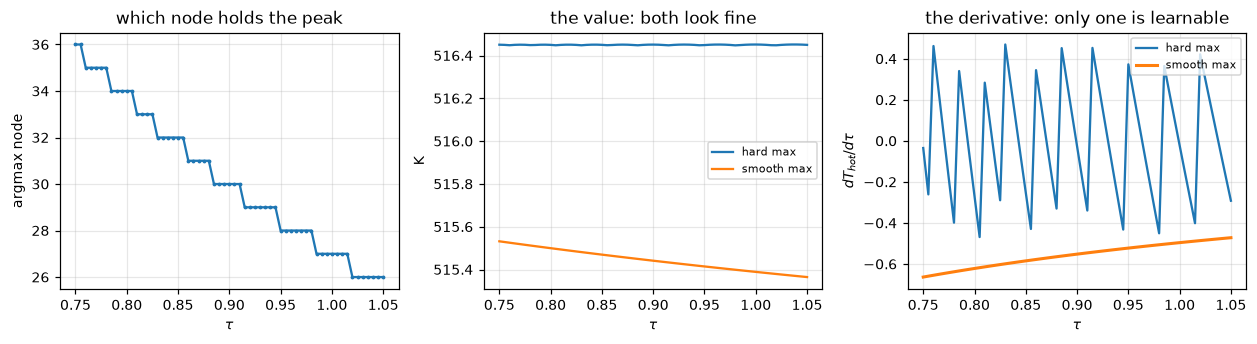

In [28]:
TS = slice(2*nz, 3*nz)
taus = np.linspace(0.75, 1.05, 61)
rows = []
for tv in taus:
    p = NOM.copy(); p[0] = tv
    s2, _ = solve(p, N)
    x = s2.base_x
    Tz = x[TS]; j = int(Tz.argmax())
    dx = (solution(s2, [0], [HJ[0]], clamp=False) - x) / HJ[0]   # d(state)/d(tau)
    rows.append((tv, j, Tz[j], dx[TS][j], x[OS][2], dx[OS][2]))
rows = np.array(rows)
sw = np.nonzero(np.diff(rows[:, 1]))[0]

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.2))
ax[0].plot(rows[:, 0], rows[:, 1], ".-", ms=3)
ax[0].set(xlabel=r"$\tau$", ylabel="argmax node", title="which node holds the peak")
ax[1].plot(rows[:, 0], rows[:, 2], label="hard max")
ax[1].plot(rows[:, 0], rows[:, 4], label="smooth max")
ax[1].set(xlabel=r"$\tau$", ylabel="K", title="the value: both look fine")
ax[1].legend(fontsize=7)
ax[2].plot(rows[:, 0], rows[:, 3], label="hard max")
ax[2].plot(rows[:, 0], rows[:, 5], lw=2, label="smooth max")
ax[2].set(xlabel=r"$\tau$", ylabel=r"$dT_{hot}/d\tau$", title="the derivative: only one is learnable")
ax[2].legend(fontsize=7)
fig.tight_layout()

dh = np.abs(np.diff(rows[:, 3])); ds = np.abs(np.diff(rows[:, 5]))
print(f"the argmax node walks {int(rows[0,1])} -> {int(rows[-1,1])} with "
      f"{len(sw)} switches across the sweep")
print(f"largest jump between consecutive derivative samples:")
print(f"  hard max    {dh.max():8.4f} K per unit tau   (median step {np.median(dh):.5f})")
print(f"  smooth max  {ds.max():8.4f} K per unit tau   (median step {np.median(ds):.5f})")
print(f"\nthe hard max's VALUE is nearly constant "
      f"({rows[:,2].min():.4f}..{rows[:,2].max():.4f} K) while its derivative sawtooths.")
print("A values-only surrogate would never notice. A Sobolev one is fed the sawtooth as truth.")

The middle panel is the trap: both definitions of the hot spot give a
perfectly reasonable-looking value. The right panel is the same two functions
differentiated. The hard max's derivative flips sign at every one of the
switches and jumps by up to 0.82 K per unit $\tau$, while its value varies by
less than 0.004 K.

This is a *label* failure, not a training failure. No loss and no architecture
recovers from being told that the truth is a sawtooth. It is also the
failure mode most likely to appear in real work, because taking a max over
discretization nodes is the obvious way to write "the hot spot", and the
resulting model solves perfectly well — the damage is invisible until something
differentiates it.

The same warning generalizes to any model whose **active set** changes across
the sampling box: a constraint that switches between active and inactive makes
$\partial y^\star/\partial p$ genuinely discontinuous there, and the derivative
labels on either side are both correct and mutually contradictory. Notebooks 40
and 41 are about exactly that discontinuity from the optimization side. A
surrogate trained across one is being asked to average two different regimes.

## 10. What this is not evidence about

Every number here comes from one reactor, one architecture, and one sampling
box. The specific things this notebook does **not** establish:

* **Any statement about large $n$.** The largest training set is 256. The
  Sobolev advantage *widens* monotonically over the measured range — 2.0&times;
  at $n=16$ to 7.8&times; at $n=256$ on values — but that is the values-only arm
  saturating rather than the Sobolev arm improving without limit, and nothing
  here says where either curve turns over. The usual intuition, that sample
  efficiency is worth less the more samples you have, is not what this corpus
  shows; do not assume either behaviour past 256.
* **Any statement about high-dimensional parameter spaces.** Five parameters
  means 20 derivative labels for 4 outputs, a 5:1 ratio of extra labels to
  values. At 50 parameters the Jacobian is 200 numbers per solve and the
  back-solve cost grows linearly, so the 1.17&times; surcharge does not hold —
  it is a measured property of *this* problem's shape, not a constant.
* **Whether the NLL helps on a different task mix.** Both NLL corrections in
  section 7 were measured at $n=64$ on 24 tasks. The finding that the profiled
  form's edge is an optimization-speed effect should transfer; the finding that
  z-scored $\lambda=1$ wins at convergence is a statement about *this* corpus
  and could easily flip where channel difficulties are more spread out.
* **Constrained or multi-solution generators.** Every solve here is a square
  feasibility problem with a unique answer. A generator that is an *optimizer*
  has active sets that change, and a nonconvex one has folds — a CSTR with
  multiplicity would hand the sampler two different answers at neighbouring
  parameters. The derivative labels are then correct and useless in the same
  breath.
* **That the surrogate is safe near the constraint.** Section 8 scores designs
  on the true model precisely because the surrogate cannot be trusted to say
  whether it violated a limit. The Sobolev arm's worst violation at $n=16$ is
  31.5 K — *worse* than the values-only arm's 28.5 K at that budget. Sobolev
  training buys accuracy, not feasibility.
* **Solver-agnosticism.** The 1.17&times; surcharge is POUNCE's interior-point
  factorization being reused. An active-set solver, or one that discards its
  factorization, gives a different number, and a solver without a sensitivity
  layer gives 7.5&times; — at which point the cost panel in section 5 is the
  one to look at.

What it does establish, on this problem: the derivative labels are nearly free,
they are exact to $10^{-5}$, they are worth roughly 4&times; in solves, and the
loss you wrap them in matters much less than whether you collected them at all.